## Exploratory Data Analysis for a collaborative filtering approach

### Imports and reading in data

In [84]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.decomposition import TruncatedSVD
import requests, io

In [66]:
# read in cleaned csvs
bills_df = pd.read_csv("../../data/bills/bills_with_topic.csv")
votes_df = pd.read_csv("../../data/votes/votes.csv")
senators_df = pd.read_csv("../../data/senators/all_senators_with_bios.csv")

### Load and build the senator-bill matrix

In [67]:
# encode vote as numeric
vote_map = {'Yea': 1, 'Nay': -1, 'Not Voting': 0, 'Present': 0}
votes_df['vote_numeric'] = votes_df['vote'].map(vote_map)
votes_df.head()

,senator_id,bill_id,vote,congress,vote_numeric
0,S180,H.R. 3402,Yea,101,1.0
1,S134,H.R. 3402,Yea,101,1.0
2,S127,H.R. 3402,Yea,101,1.0
3,S009,H.R. 3402,Yea,101,1.0
4,S010,H.R. 3402,Yea,101,1.0


In [68]:
# pivot to senator x bill matrix
vote_matrix = votes_df.pivot_table(
    index='senator_id',
    columns='bill_id',
    values='vote_numeric'
)
vote_matrix.head()

bill_id,H.Con.Res. 64,H.Con.Res. 67,H.Con.Res. 68,H.J.Res. 116,H.R. 1,H.R. 10,H.R. 1025,H.R. 1048,H.R. 10545,H.R. 1058,...,S. 914,S. 933,S. 937,S. 942,S. 954,S. 978,S.Con.Res. 83,S.Res. 57,S.Res. 71,Treaty Doc. 102-32
senator_id,,,,,,,,,,,,,,,,,,,,,
S009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
S010,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,NaN,-1.0,...,NaN,1.0,NaN,1.0,NaN,1.0,-1.0,1.0,1.0,1.0
S014,1.0,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,-1.0,...,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN,1.0,1.0
S015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S017,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,NaN,-1.0,...,NaN,1.0,NaN,1.0,NaN,1.0,-1.0,1.0,1.0,1.0


In [69]:
# fill NaN with 0 for computation — missing vote treated as no signal
vote_matrix_filled = vote_matrix.fillna(0).values
senator_ids = vote_matrix.index.tolist()
bill_ids = vote_matrix.columns.tolist()

print(f'Matrix shape: {vote_matrix.shape}')
print(f'--> Number of bills voted on: {len(vote_matrix.columns)}')
print(f'--> Number of senators: {len(vote_matrix)}')
print(f'Sparsity: {vote_matrix.isna().mean().mean()*100}% are missing')

Matrix shape: (326, 700)
--> Number of bills voted on: 700
--> Number of senators: 326
Sparsity: 68.29228746713409% are missing


## Method 1: User-User Collaborative Filtering

Computes the cosine similarity between every pair of senators based on their votes on past bills. To predict a senator's vote on a bill they didn't vote on, take a weighted average of the K most similar senators who did vote on that bill.

In [70]:
# compute senator-senator cosine similarity matrix
sim_matrix = cosine_similarity(vote_matrix_filled)
sim_df = pd.DataFrame(sim_matrix, index=senator_ids, columns=senator_ids)
print(f'Similarity matrix shape: {sim_df.shape}')
print(f'Mean similarity between senators: {sim_matrix[sim_matrix < 1].mean()}')

Similarity matrix shape: (326, 326)
Mean similarity between senators: 0.1534828002651108


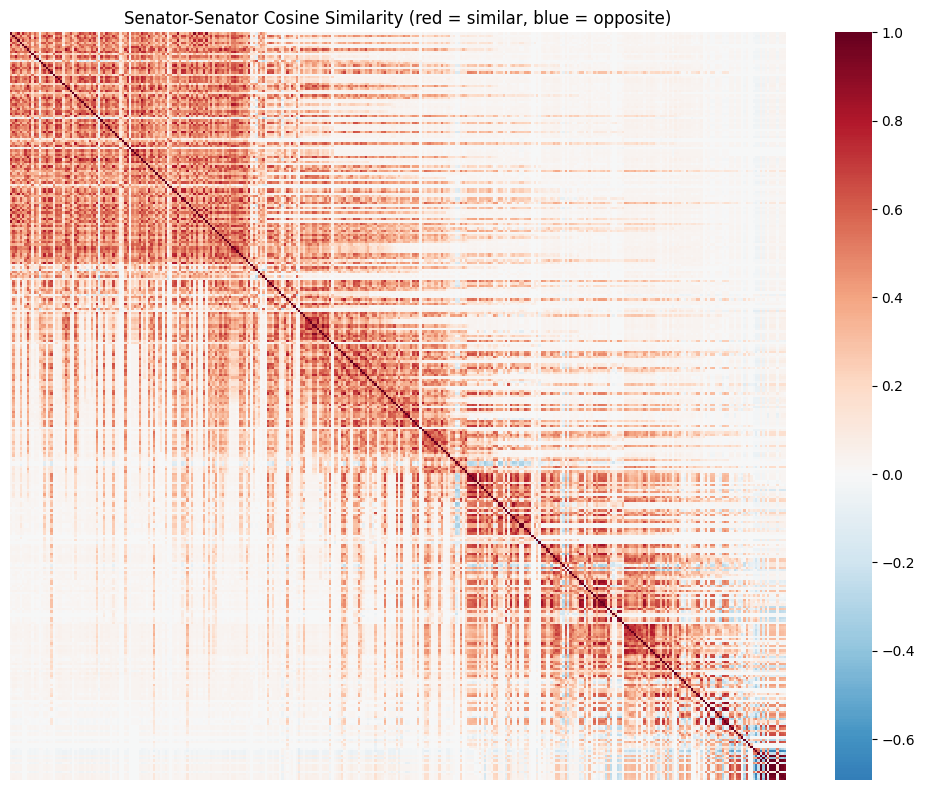

In [71]:
# visualize the similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(sim_df.values, cmap='RdBu_r', center=0, xticklabels=False, yticklabels=False)
plt.title('Senator-Senator Cosine Similarity (red = similar, blue = opposite)')
plt.tight_layout()
plt.show()

In [72]:
def predict_vote_memory(senator_id, bill_id, vote_matrix, sim_df, k=10):
    """
    Predict how senator_id would vote on bill_id using the K most similar senators who actually voted on that bill.

    Args:
        senator_id (str): Identifier for the senator whose vote is being predicted.
        bill_id (str): Identifier for the bill to predict a vote on.
        vote_matrix (pd.DataFrame): Senator × bill matrix of vote values, where 1 = Yea, -1 = Nay, 0 = Abstain, and NaN = did not vote.
        sim_df (pd.DataFrame): Square senator × senator cosine similarity matrix, indexed and columned by senator_id.
        k (int): Number of most similar neighbors to use in the prediction. Defaults to 10.

    Returns:
        float: A similarity-weighted average of neighbor votes in [-1, 1], where positive 
            values indicate a predicted Yea and negative values a predicted Nay.
        None: If the bill is not in the vote matrix, the senator is not in the similarity matrix, 
            no other senators voted on the bill, or all neighbor similarity scores are zero.
    """
    # check that the bill exists
    if bill_id not in vote_matrix.columns:
        return None

    # filter for all of the senators who voted on this bill
    bill_votes = vote_matrix[bill_id].dropna()

    # filter out senators who abstained from the vote
    bill_votes = bill_votes[bill_votes != 0]
    other_senators = bill_votes.index.tolist()
    if senator_id not in sim_df.index or len(other_senators) == 0:
        return None

    # get similarity scores to senators who voted on this bill
    similarities = sim_df.loc[senator_id, other_senators]

    # take top K most similar, excluding self
    similarities = similarities[similarities.index != senator_id]
    top_k = similarities.nlargest(k)
    if top_k.sum() == 0:
        return None

    # weighted average of their votes
    weighted_votes = sum(top_k[s] * bill_votes[s] for s in top_k.index)
    prediction = weighted_votes / top_k.abs().sum()
    return prediction

### Sample usage of the `predict_vote_memory` user-use CF appraoach

In [73]:
# example usage 1 -- predicting a known vote and comparing to the actual vote
sample_senator = senator_ids[0]
sample_bill = bill_ids[0]
actual_vote = vote_matrix.loc[sample_senator, sample_bill]

pred = predict_vote_memory(sample_senator, sample_bill, vote_matrix, sim_df, k=10)
print(f'Senator: {sample_senator}')
print(f'Bill: {sample_bill}')
print(f'Actual: {actual_vote} ({"Yea" if actual_vote == 1 else "Nay" if actual_vote == -1 else "Abstain"})')
print(f'Predicted score: {pred:.3f} ({"leans Yea" if pred > 0 else "leans Nay"})')

Senator: S009
Bill: H.Con.Res. 64
Actual: nan (Abstain)
Predicted score: 0.631 (leans Yea)


In [74]:
# example usage 2 -- predicting a known vote and comparing to the actual vote
sample_senator = senator_ids[1]
sample_bill = bill_ids[1]
actual_vote = vote_matrix.loc[sample_senator, sample_bill]

pred = predict_vote_memory(sample_senator, sample_bill, vote_matrix, sim_df, k=10)
print(f'Senator: {sample_senator}')
print(f'Bill: {sample_bill}')
print(f'Actual: {actual_vote} ({"Yea" if actual_vote == 1 else "Nay" if actual_vote == -1 else "Abstain"})')
print(f'Predicted score: {pred:.3f} ({"leans Yea" if pred > 0 else "leans Nay"})')

Senator: S010
Bill: H.Con.Res. 67
Actual: 1.0 (Yea)
Predicted score: 1.000 (leans Yea)


In [75]:
# example usage 3 -- predicting a known vote and comparing to the actual vote
sample_senator = senator_ids[55]
sample_bill = bill_ids[99]
actual_vote = vote_matrix.loc[sample_senator, sample_bill]

pred = predict_vote_memory(sample_senator, sample_bill, vote_matrix, sim_df, k=10)
print(f'Senator: {sample_senator}')
print(f'Bill: {sample_bill}')
print(f'Actual: {actual_vote} ({"Yea" if actual_vote == 1 else "Nay" if actual_vote == -1 else "Abstain"})')
print(f'Predicted score: {pred:.3f} ({"leans Yea" if pred > 0 else "leans Nay"})')

Senator: S144
Bill: H.R. 2356
Actual: nan (Abstain)
Predicted score: 0.794 (leans Yea)


### Evaluation of the user-user CF model

In [76]:
# hide known votes and try to predict them -- sample 500 known (non-zero, non-NaN) votes to evaluate on
known_votes = votes_df[votes_df['vote_numeric'] != 0][['senator_id', 'bill_id', 'vote_numeric']]
sample = known_votes.sample(n=min(500, len(known_votes)), random_state=42)

# intialize empty lists
actuals = []
predictions = []

# loop through sample votes
for _, row in sample.iterrows():
    pred = predict_vote_memory(row['senator_id'], row['bill_id'], vote_matrix, sim_df, k=10)
    if pred is not None:
        actuals.append(row['vote_numeric'])
        predictions.append(pred)

# convert continuous prediction to binary (-1 or 1) for accuracy
pred_binary = [1 if p > 0 else -1 for p in predictions]
mae = mean_absolute_error(actuals, predictions)
acc = accuracy_score(actuals, pred_binary)

# print results
print(f'Memory-based results (n={len(actuals)} predictions):')
print(f'--> Accuracy: {acc}')
print(f'--> MAE: {mae}')

Memory-based results (n=481 predictions):
--> Accuracy: 0.9230769230769231
--> MAE: 0.2176812208714663


### Finding the most similar and opposite pairs of senators

In [77]:
# similar - lower negative similarity
sim_upper = sim_df.where(np.triu(np.ones(sim_df.shape), k=1).astype(bool))
top_pairs = (
    sim_upper.stack()
    .reset_index()
    .rename(columns={'senator_id': 'senator_a', 'bill_id': 'senator_b', 0: 'similarity'})
    .sort_values('similarity', ascending=False)
    .head(10)
)
print('Most similar senator pairs:')
print(top_pairs.to_string(index=False))

Most similar senator pairs:
level_0 level_1  similarity
   S431    S435         1.0
   S433    S435         1.0
   S433    S434         1.0
   S433    S437         1.0
   S434    S437         1.0
   S431    S437         1.0
   S431    S434         1.0
   S434    S435         1.0
   S431    S433         1.0
   S435    S437         1.0


In [78]:
# opposite - highest negative similarity
bottom_pairs = (
    sim_upper.stack()
    .reset_index()
    .rename(columns={'senator_id': 'senator_a', 'bill_id': 'senator_b', 0: 'similarity'})
    .sort_values('similarity', ascending=True)
    .head(10)
)
print('Most opposite senator pairs:')
print(bottom_pairs.to_string(index=False))

Most opposite senator pairs:
level_0 level_1  similarity
   S427    S437   -0.692308
   S427    S435   -0.692308
   S427    S434   -0.692308
   S427    S433   -0.692308
   S427    S431   -0.692308
   S427    S429   -0.662344
   S427    S438   -0.640513
   S427    S439   -0.585369
   S417    S427   -0.547949
   S416    S427   -0.471728


## Method 2: Model-Based Collaborative-Filtering: Single Value Decomposition Matrix Factorization

Implement a Model-Based Collaborative-Filtering approach that uses Single Value Decomposition to factor the senator-bill vote matrix into low-dimensional embeddings for each senator's ideology and each bill's ideological lean. The senator's vote is predicted by calculating the dot product of the two embeddings.

After calculating the senator's ideology using their votes, we compare this value for each senator to their NOMINATE ideology score.

### Initiative SVD and investigate shape and attributes of data 

In [79]:
# fit SVD with n_components, starting with 20 to capture variance without overfitting
N_COMPONENTS = 20

# intitialize SVD using TruncatedSVD
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)

# initiliaze 326 senators and 700 bills 
senator_factors = svd.fit_transform(vote_matrix_filled)
bill_factors = svd.components_

# info about bills and senators
print(f'Senator factors shape: {senator_factors.shape}')
print(f'Bill factors shape: {bill_factors.shape}\n')
print(f'Variance explained by each component:')
print(np.round(svd.explained_variance_ratio_, 3))
print(f'--> Total variance explained: {svd.explained_variance_ratio_.sum()*100}%')

Senator factors shape: (326, 20)
Bill factors shape: (20, 700)

Variance explained by each component:
[0.193 0.136 0.097 0.068 0.044 0.03  0.024 0.017 0.015 0.013 0.011 0.01
 0.009 0.008 0.008 0.007 0.007 0.006 0.006 0.006]
--> Total variance explained: 71.71814956055009%


In [80]:
# reconstruct the full matrix from the factorization
reconstructed = senator_factors @ bill_factors
print(f'Reconstructed matrix shape: {reconstructed.shape}')
print(f'--> Smallest value: [{reconstructed.min()}')
print(f'--> Largest value: [{reconstructed.max()}]')

Reconstructed matrix shape: (326, 700)
--> Smallest value: [-1.8114452752751826
--> Largest value: [2.1921712984555795]


### Evaluate SVD model on the same 500 sample votes

In [81]:
# initialize senator and bill information
senator_idx = {s: i for i, s in enumerate(senator_ids)}
bill_idx  = {b: i for i, b in enumerate(bill_ids)}
actuals_svd = []
predictions_svd = []

# loop through bills and senators, and compare accuracy of predictions to actual
for _, row in sample.iterrows():
    sid = row['senator_id']
    bid = row['bill_id']
    if sid in senator_idx and bid in bill_idx:
        pred = reconstructed[senator_idx[sid], bill_idx[bid]]
        actuals_svd.append(row['vote_numeric'])
        predictions_svd.append(pred)

pred_binary_svd = [1 if p > 0 else -1 for p in predictions_svd]
mae_svd = mean_absolute_error(actuals_svd, predictions_svd)
acc_svd = accuracy_score(actuals_svd, pred_binary_svd)

# print results
print(f'SVD results (n={len(actuals_svd)} predictions):')
print(f'--> Accuracy: {acc_svd}')
print(f'--> MAE: {mae_svd}')

SVD results (n=481 predictions):
--> Accuracy: 0.9334719334719335
--> MAE: 0.3002275375643061


### Investigating senator ideology

In [82]:
# setting up to compare SVD component to NOMINATE ideology scores
senator_dim1 = senator_factors[:, 0]
svd_ideology = pd.DataFrame({
    'senator_id':  senator_ids,
    'svd_dim1': senator_dim1,
    'svd_dim2': senator_factors[:, 1]
})
svd_ideology = svd_ideology.sort_values('svd_dim1')

# print three most liberal and conservative senators
print('Most liberal senators by SVD dim1 (most negative):')
print(svd_ideology.head(3)[['senator_id', 'svd_dim1']].to_string(index=False))
print('\nMost conservative senators by SVD dim1 (most positive):')
print(svd_ideology.tail(3)[['senator_id', 'svd_dim1']].to_string(index=False))

Most liberal senators by SVD dim1 (most negative):
senator_id  svd_dim1
      S346 -0.514113
      S348 -0.318987
      S119 -0.289598

Most conservative senators by SVD dim1 (most positive):
senator_id  svd_dim1
      S198 20.527006
      S136 20.626152
      S182 20.720685


In [83]:
# senators info dataframe
senators_df.head(3)

,id,givenName,familyName,middleName,honorificSuffix,birthYear,deathYear,num_terms,positions,states,parties,congress_range,bio,nominate_dim1_x,nominate_dim2_x,govtrack_ideology_score_x,nominate_dim1_y,nominate_dim2_y,govtrack_ideology_score_y
0,A000001,Fred,Aandahl,George,NaN,1897.0,1966.0,1,['Representative'],['ND'],['Republican'],82-82,"AANDAHL, Fred George, a Representative from No...",NaN,NaN,NaN,NaN,NaN,NaN
1,A000002,Watkins,Abbitt,Moorman,NaN,1908.0,1998.0,13,['Representative'],['VA'],['Democrat'],80-92,"ABBITT, Watkins Moorman, a Representative from...",NaN,NaN,NaN,NaN,NaN,NaN
2,A000003,Joel,Abbot,NaN,NaN,1776.0,1826.0,4,['Representative'],['GA'],"['Democratic Republican', 'Crawford Republican']",15-18,"Crawford Republican\nABBOT, Joel, a Representa...",NaN,NaN,NaN,NaN,NaN,NaN


### Comparing SVD and NOMINATE scores

In [91]:
# compare SVD dim1 to NOMINATE dim1
senators_df = pd.read_csv('../../data/senators/all_senators_with_bios.csv')
ideology_merge = svd_ideology.merge(
    senators_df[['id', 'nominate_dim1_y']],
    left_on='senator_id', right_on='id',
    how='inner'
).dropna(subset=['nominate_dim1_y'])

In [93]:
ideology_merge # agh not workingggg

,senator_id,svd_dim1,svd_dim2,icpsr,id,nominate_dim1_y


In [92]:
# calculate the correlation between the ideology score calculated using SVD and NOMINATE
correlation = ideology_merge['svd_dim1'].corr(ideology_merge['nominate_dim1_y'])
print(f'Correlation between SVD and NOMINATE: {correlation}')

Correlation between SVD and NOMINATE: nan


In [ ]:
# plotting to compare SVD and NOMINATE
plt.figure(figsize=(8, 6))
plt.scatter(ideology_merge['nominate_dim1_y'], ideology_merge['svd_dim1'], alpha=0.6)
plt.xlabel('NOMINATE dim1 (liberal ← → conservative)')
plt.ylabel('SVD dim1 (learned from votes)')
plt.title(f'SVD vs NOMINATE Ideology Score\nCorrelation: {correlation:.3f}')
plt.tight_layout()
plt.show()

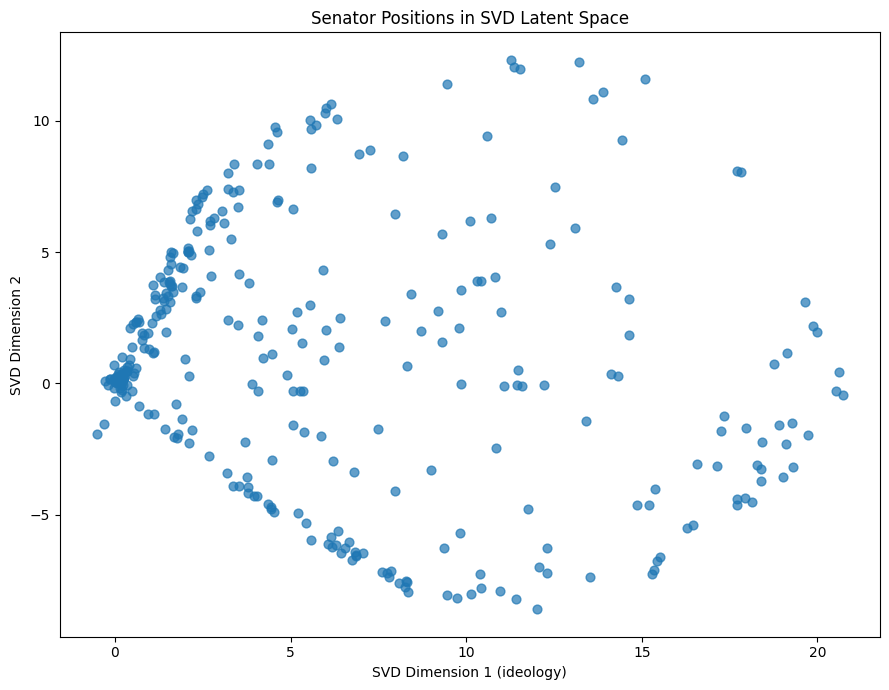

In [17]:
# plot senators
plt.figure(figsize=(9, 7))
plt.scatter(
    svd_ideology['svd_dim1'],
    svd_ideology['svd_dim2'],
    alpha=0.7, s=40
)
plt.xlabel('SVD Dimension 1 (ideology)')
plt.ylabel('SVD Dimension 2')
plt.title('Senator Positions in SVD Latent Space')
plt.tight_layout()
plt.show()

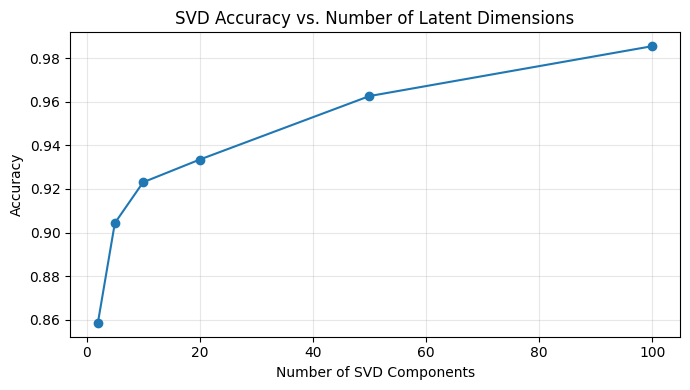

Best n_components: 100 (accuracy: 0.985)


In [18]:
# n_components: check accuracy vs. number of latent dimensions
component_range = [2, 5, 10, 20, 50, 100]
accuracies = []

for n in component_range:
    if n >= min(vote_matrix_filled.shape):
        break
    svd_test = TruncatedSVD(n_components=n, random_state=42)
    sf = svd_test.fit_transform(vote_matrix_filled)
    bf = svd_test.components_
    recon = sf @ bf

    preds = []
    acts  = []
    for _, row in sample.iterrows():
        sid = row['senator_id']
        bid = row['bill_id']
        if sid in senator_idx and bid in bill_idx:
            preds.append(1 if recon[senator_idx[sid], bill_idx[bid]] > 0 else -1)
            acts.append(row['vote_numeric'])

    accuracies.append(accuracy_score(acts, preds))

plt.figure(figsize=(7, 4))
plt.plot(component_range[:len(accuracies)], accuracies, marker='o')
plt.xlabel('Number of SVD Components')
plt.ylabel('Accuracy')
plt.title('SVD Accuracy vs. Number of Latent Dimensions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# print best components
best_n = component_range[np.argmax(accuracies)]
print(f'Best n_components: {best_n} (accuracy: {max(accuracies):.3f})')

## Summary and comparing method 1 and 2
The SVD matrix factorization approach had a slightly higher accuracy than the User-user CF approach.

In [95]:
print(f'User-user CF (k=10 most similar senators):')
print(f'--> Accuracy: {acc}, MAE: {mae}\n')
print(f'SVD matrix factorization (n={N_COMPONENTS} components):')
print(f'--> Accuracy: {acc_svd},  MAE: {mae_svd}\n')

User-user CF (k=10 most similar senators):
--> Accuracy: 0.9230769230769231, MAE: 0.2176812208714663

SVD matrix factorization (n=20 components):
--> Accuracy: 0.9334719334719335,  MAE: 0.3002275375643061

